# Modeling

It is the main nootebook related to building prediction models for https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv dataset.

Previous notbook related to data preprocessing and feature engineering - https://github.com/Maxstef/ml-bank-additional-project/blob/main/notebooks/02_preprocessing.ipynb.

All intermediate conclusions are provided at the end of each section and marked with <span style="background-color: #4FC3F7">light-blue background</span>

Final results and conclusions are provided in the last section at the end of the notebook.


## Notebook initialization

In [1]:
# Notebook initialization
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd()

while not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# print("Project root:", ROOT)

## Imports & Load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import f1_score, roc_auc_score


from src.data import load_raw_data

raw_df = load_raw_data()
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
target_col = "y"

## Split Data Train & Validation

In [4]:
from src.data import split_train_val, split_X_y

train_df, val_df = split_train_val(raw_df, stratify_col=target_col)

X_train, X_val, y_train, y_val = split_X_y(train_df, val_df, target_col)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((32950, 20), (8238, 20), (32950,), (8238,))

## Experiments Preparation & Results Tracking

In this section we set up a simple framework for running and tracking modeling experiments.

We reuse the `build_pipeline` function implemented in the [previous notebook](https://github.com/Maxstef/ml-bank-additional-project/blob/main/notebooks/02_preprocessing.ipynb) to construct configurable preprocessing and modeling pipelines.

An empty `results_df` DataFrame is created to store the results of all experiments performed in this notebook.

To automate experiment tracking, we implement an `experiment_logger` decorator that logs model parameters, pipeline configuration, and evaluation metrics (F1 and AUROC for train/test).

The `train_pipeline` function builds and fits the pipeline. Since it is decorated with `experiment_logger`, each call automatically records the experiment results in `results_df`.

`show_results_df` can be used to display what there is in `results_df`

In [5]:
from src.modeling.experiments import train_pipeline, show_results_df
from src.pipelining import build_pipeline

## Base Models

Use LogisticRegression, KNeighborsClassifier and DecisionTreeClassifier as base models experiments

### Baseline models
Train few baseline models with default model and pipeline params

In [6]:
base_models = [
    LogisticRegression(solver="liblinear", random_state=42),
    KNeighborsClassifier(),
    DecisionTreeClassifier(max_leaf_nodes=100, random_state=42), # Limit max_leaf_nodes=100 to avoid overfitting
]

for base_model in base_models:
    train_pipeline(X_train, X_val, y_train, y_val,
    {
        "model": base_model
    }
)

In [7]:
show_results_df()

,model_name,fit_time,train_f1,val_f1,train_auroc,val_auroc
2,DecisionTreeClassifier,0.204769,0.453556,0.409956,0.795127,0.790793
1,KNeighborsClassifier,0.111454,0.489868,0.389088,0.926570,0.746676
0,LogisticRegression,0.175928,0.338881,0.336859,0.792307,0.800603


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Conclusions from baseline models:**

- The baseline **DecisionTreeClassifier** achieves the best **validation F1 score**, indicating the best performance on the classification objective among baseline models.
- The baseline **LogisticRegression** achieves the best **validation AUROC**, which is expected since logistic regression produces well-calibrated probability estimates.
- The **KNeighborsClassifier** shows the highest scores on the **training set** but noticeably worse performance on the **validation set**, suggesting a tendency to **overfit** the training data.

</span>

### Logistic Regression

#### Feature Statistical Significance

In this section, we explore the **statistical significance of features** for the baseline Logistic Regression model using `statsmodels.Logit`.

This allows us to:

- Estimate **coefficient significance** (p-values) for each feature  
- Identify which features **increase or decrease** the probability of the target outcome  
- Gain insights into the **most influential predictors** in our model  
- Verify whether the assumptions made in the **EDA step** were correct

Features with **p-values below 0.05** are considered statistically significant.

In [8]:
import statsmodels.api as sm

# STEP 1 - train pipeline avoiding any multicollinearity or other stuff that might spoil statistics
pipe_lr = train_pipeline(X_train, X_val, y_train, y_val,
    {
        "poly_degree": 1,                   # no poly features
        "drop_cols": None,                  # include all cols here (except of "duration")
        "pdays_transform_mode": "binary",   # "binary" to avoid multicollinearity and all p-values 1
        "drop_cats": {                      # drop at least one value per each category to avoid multicollinearity and all p-values 1
            "job": ["unknown"],
            "marital": ["unknown"],
            "education": ["unknown", "illiterate"],
            "default": ["no"],
            "housing": ["yes"],
            "loan": ["yes"],
            "contact": ["telephone"],
            "month": ["dec"],
            "day_of_week": ["fri"],
            "poutcome": ["nonexistent"],
        },
        "model": base_models[0],            # LogisticRegression(solver="liblinear", random_state=42)
    }
)

# STEP 2 - get transformet input data and feature names
X_train_transformed = pipe_lr[:-1].transform(X_train)
feature_names = pipe_lr.named_steps["preprocessing"].get_feature_names_out()
X_train_df = pd.DataFrame(
    X_train_transformed,
    columns=feature_names,
    index=X_train.index
)

# STEP 3 - fit sm.Logit for calculating statistics
X_train_df_const = sm.add_constant(X_train_df)
logit_model = sm.Logit(y_train.map({"no":0, "yes":1}), X_train_df_const)
stats_result_lr = logit_model.fit()

# STEP 4 - print all statistics
print(stats_result_lr.summary())

Optimization terminated successfully.
         Current function value: 0.277034
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                32950
Model:                          Logit   Df Residuals:                    32900
Method:                           MLE   Df Model:                           49
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                  0.2130
Time:                        14:16:58   Log-Likelihood:                -9128.3
converged:                       True   LL-Null:                       -11599.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                 -1.6929      0.485    

In [9]:
# STEP 5 - print features sorted by significance (p-value) - round to 3 decimal and sort by raw p-value
significance_df = pd.DataFrame({
    "feature": stats_result_lr.params.index,
    "coef": stats_result_lr.params.values.round(3),
    "p_value": stats_result_lr.pvalues.values.round(3),
    "p_value_raw": stats_result_lr.pvalues.values,
})

significance_df = significance_df.sort_values("p_value_raw")

significance_df[["feature", "coef", "p_value"]]

,feature,coef,p_value
45,numeric__emp.var.rate,-2.395,0.000
26,cat__contact_cellular,0.751,0.000
46,numeric__cons.price.idx,1.285,0.000
50,numeric__pdays_contacted,0.217,0.000
30,cat__month_jun,-1.262,0.000
32,cat__month_may,-0.955,0.000
33,cat__month_nov,-0.954,0.000
31,cat__month_mar,0.977,0.000
40,cat__poutcome_failure,-0.398,0.000
47,numeric__cons.conf.idx,0.149,0.000


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Feature Statistical Significance – Conclusions**

- Most **socio-economic context features** are statistically significant, except for `euribor3m`. This aligns with our EDA assumption that `euribor3m` is highly correlated with other socio-economic features and does not add new information to the model.  
- The features `previous` and raw `pdays` do not show statistical significance in the Logistic Regression model. This may be due to strong **class imbalance** (e.g., only ~4% of rows have `pdays != 999`). They might still be useful for **tree-based models**.  
- Transformed `pdays` to binary `pdays_contacted` feature shows strong statistical significance which confirms EDA assumption that `pdays` contains important for target prediction details even despite of strong **values imbalance** of `pdays`.
- Numeric `age` does not appear significant as-is; using **binned age groups** may improve linear model performance, while tree-based models can handle raw numeric values.  
- Most **month** and **day_of_week** values are significant, suggesting **time-related effects** influence the target.  
- `housing` and `loan` remain insignificant, consistent with the EDA assumptions.  
- No statistically significant effects are observed for categorical variables `education`, `marital`, or `job` in the Logistic Regression model. This may be due to **high cardinality**.  
- Features such as `poutcome_failure`, `default_risk`, `contact_cellular`, and `campaign` are significant predictors of the target.

Overall, these results largely confirm the patterns observed in EDA and provide guidance for **feature selection and transformations** for linear models.
</span>

#### Drop Columns

Experiment with dropping additional columns for the Logistic Regression model based on the statistical significance analysis above.

In [10]:
# define some drop columns options for experimenting based on stats significans experiment above
drop_cols_options = [
    ["duration"],
    ["duration", "loan", "housing"],
    ["duration", "loan", "housing", "euribor3m"],
    ["duration", "loan", "housing", "euribor3m", "job"],
    ["duration", "loan", "housing", "euribor3m", "pdays"],
    ["duration", "loan", "housing", "euribor3m", "age"],
    ["duration", "loan", "housing", "euribor3m", "previous"],
    ["duration", "loan", "housing", "euribor3m", "job", "marital"],
    ["duration", "loan", "housing", "euribor3m", "job", "education", "marital"],
    ["duration", "loan", "housing", "euribor3m", "job", "education", "marital", "age"],
    ["duration", "loan", "housing", "euribor3m", "job", "education", "marital", "pdays"],
    ["duration", "loan", "housing", "euribor3m", "pdays", "age"],
    ["duration", "loan", "housing", "euribor3m", "pdays", "age", "previous"],
    ["duration", "loan", "housing", "euribor3m", "job", "pdays", "age", "previous"],
    ["duration", "loan", "housing", "euribor3m", "job", "education", "marital", "pdays", "previous"],
    ["duration", "loan", "housing", "euribor3m", "job", "education", "marital", "pdays", "previous", "age"],
]

In [11]:
for drop_cols in drop_cols_options:
    train_pipeline(X_train, X_val, y_train, y_val,
        {
            "drop_cols": drop_cols,
            "model": base_models[0],
        }
    )

In [12]:
show_results_df(
    model_name="LogisticRegression",
    show_cols=["model_name", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "pipe__drop_cols", "n_features"],
)

,model_name,fit_time,train_f1,val_f1,train_auroc,val_auroc,pipe__drop_cols,n_features
6,LogisticRegression,0.153921,0.340340,0.338762,0.792146,0.800909,"[duration, loan, housing, euribor3m]",49
9,LogisticRegression,0.163773,0.341337,0.338487,0.792127,0.800892,"[duration, loan, housing, euribor3m, age]",48
5,LogisticRegression,0.181692,0.338412,0.337959,0.792174,0.801070,"[duration, loan, housing]",50
10,LogisticRegression,0.171802,0.337678,0.337134,0.792060,0.800951,"[duration, loan, housing, euribor3m, previous]",48
13,LogisticRegression,0.124132,0.338697,0.336894,0.790767,0.802239,"[duration, loan, housing, euribor3m, job, education, marital, age]",28
0,LogisticRegression,0.175928,0.338881,0.336859,0.792307,0.800603,NaN,56
4,LogisticRegression,0.217763,0.338881,0.336859,0.792307,0.800603,[duration],56
12,LogisticRegression,0.127448,0.338765,0.335526,0.790632,0.802208,"[duration, loan, housing, euribor3m, job, education, marital]",29
19,LogisticRegression,0.107300,0.334682,0.334975,0.790245,0.802290,"[duration, loan, housing, euribor3m, job, education, marital, pdays, previous, age]",26
7,LogisticRegression,0.155940,0.338969,0.334975,0.791378,0.800879,"[duration, loan, housing, euribor3m, job]",38


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Feature Removal Experiments – Logistic Regression Conclusions**

- Removing `loan`, `housing` does **not affect model performance**, confirming their low predictive value.
- Excluding the correlated feature `euribor3m` also **does not degrade validation metrics**, suggesting redundancy with other macroeconomic variables.
- Removing additional variables (`age`, `previous`, `job`, `education`, `marital`) leads to **only minor changes in F1**, while **AUROC remains stable (~0.80)**.
- Even with aggressive feature reduction (59 → ~26 features), the model maintains **similar predictive performance** and **faster training time**.
- These results are **consistent with the earlier statistical significance exploration**, which showed that many of these features have limited impact on the Logistic Regression model.

**Summary**

Logistic Regression performance is **robust to feature removal**, confirming that a **smaller subset of features can achieve comparable results**, matching the insights from the statistical significance analysis.

</span>

#### Polynomial Degree

Create polynomial degree features for the Logistic Regression experiment.

In [13]:
poly_degree_options = [1,2,3,4]

for poly_degree in poly_degree_options:
    train_pipeline(X_train, X_val, y_train, y_val,
        {
            "poly_degree": poly_degree,
            "drop_cols": ["duration", "loan", "housing", "euribor3m", "age"],
            "model": base_models[0],
        }
    )

/opt/miniconda3/envs/mlbank2/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [14]:
show_results_df(
    model_name="LogisticRegression",
    show_cols=["model_name", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "pipe__poly_degree", "n_features"],
    show_count=10,
)

,model_name,fit_time,train_f1,val_f1,train_auroc,val_auroc,pipe__poly_degree,n_features
23,LogisticRegression,75.791231,0.370093,0.340048,0.800309,0.800258,4.0,370
6,LogisticRegression,0.153921,0.340340,0.338762,0.792146,0.800909,NaN,49
20,LogisticRegression,0.152216,0.341337,0.338487,0.792127,0.800892,1.0,48
9,LogisticRegression,0.163773,0.341337,0.338487,0.792127,0.800892,NaN,48
21,LogisticRegression,0.564878,0.344524,0.338235,0.794686,0.801383,2.0,76
5,LogisticRegression,0.181692,0.338412,0.337959,0.792174,0.801070,NaN,50
22,LogisticRegression,5.584254,0.359769,0.337408,0.797929,0.801328,3.0,160
10,LogisticRegression,0.171802,0.337678,0.337134,0.792060,0.800951,NaN,48
13,LogisticRegression,0.124132,0.338697,0.336894,0.790767,0.802239,NaN,28
4,LogisticRegression,0.217763,0.338881,0.336859,0.792307,0.800603,NaN,56


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Polynomial Feature Experiments – Logistic Regression Conclusions**

- **Degree 1 (linear)** gives baseline performance: val F1 ~0.338–0.339, AUROC ~0.801, minimal training time.
- **Degree 2–4** slightly increase training F1 but **do not improve validation F1**, showing **overfitting**. Feature count and training time grow substantially.
- **Conclusion:** Linear features are sufficient; polynomial expansion adds complexity without improving validation performance

</span>

#### Age Binning

Experiment with grouping the numeric `age` feature into categorical groups.

In [15]:
age_bin_mode_options = [None, "group", "range"]

for age_bin_mode in age_bin_mode_options:
    train_pipeline(X_train, X_val, y_train, y_val,
            {
                "age_bin_mode": age_bin_mode,
                "drop_cols": ["duration", "loan", "housing", "euribor3m"],
                "model": base_models[0],
            }
        )

In [16]:
show_results_df(
    model_name="LogisticRegression",
    show_cols=["model_name", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "pipe__age_bin_mode", "n_features"],
    show_count=6,
)

,model_name,fit_time,train_f1,val_f1,train_auroc,val_auroc,pipe__age_bin_mode,n_features
25,LogisticRegression,0.169769,0.344112,0.344939,0.792328,0.801210,group,51
26,LogisticRegression,0.181487,0.341054,0.341977,0.792473,0.801027,range,54
23,LogisticRegression,75.791231,0.370093,0.340048,0.800309,0.800258,NaN,370
6,LogisticRegression,0.153921,0.340340,0.338762,0.792146,0.800909,NaN,49
24,LogisticRegression,0.153250,0.340340,0.338762,0.792146,0.800909,None,49
20,LogisticRegression,0.152216,0.341337,0.338487,0.792127,0.800892,NaN,48


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Age Binning – Logistic Regression - Conclusions**

- Grouping the numeric `age` feature into **three categories (young / middle / old)** improves the model's performance.  
- Creating **more detailed age ranges** also improves performance, but the **three-category grouping appears to provide the best balance**.

</span>

#### Pdays Binning

Experiment with grouping the numeric `pdays` feature into categorical or binary groups.

In [17]:
pdays_transform_mode_options = [None, "binary", "group"]

for pdays_transform_mode in pdays_transform_mode_options:
    train_pipeline(X_train, X_val, y_train, y_val,
        {
            "pdays_transform_mode": pdays_transform_mode,
            "age_bin_mode": "group",
            "drop_cols": ["duration", "loan", "housing", "euribor3m"],
            "model": base_models[0],
        }
    )

In [18]:
show_results_df(
    model_name="LogisticRegression",
    show_cols=["model_name", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "pipe__pdays_transform_mode", "n_features"],
    show_count=5,
)

,model_name,fit_time,train_f1,val_f1,train_auroc,val_auroc,pipe__pdays_transform_mode,n_features
29,LogisticRegression,0.253999,0.341522,0.345219,0.792337,0.801231,group,53
28,LogisticRegression,0.175849,0.344112,0.344939,0.792331,0.801198,binary,51
27,LogisticRegression,0.145900,0.344112,0.344939,0.792328,0.801210,None,51
25,LogisticRegression,0.169769,0.344112,0.344939,0.792328,0.801210,NaN,51
26,LogisticRegression,0.181487,0.341054,0.341977,0.792473,0.801027,NaN,54


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Pdays Binning – Logistic Regression - Conclusions**

- Grouping the numeric `pdays` feature into **three categories (not_contacted_before / contacted_recently / contacted_long_ago)** improves the model's performance.  
- Creating simple **binary `pdays_contacted` feature** also improves performance, but the **three-category grouping appears to provide the best balance**.

</span>

#### Cyclical Encoding for Calendar Columns

Experiment with different encoding strategies for the `month` and `day_of_week` features.

In [19]:
calendar_cols_mode_options = ["onehot", "num", "cyclical"]

for calendar_cols_mode in calendar_cols_mode_options:
    train_pipeline(X_train, X_val, y_train, y_val,
        {
            "calendar_cols_mode": calendar_cols_mode,
            "age_bin_mode": "group",
            "pdays_transform_mode": "group",
            "drop_cols": ["duration", "loan", "housing", "euribor3m"],
            "model": base_models[0],
        }
    )

In [20]:
show_results_df(
    model_name="LogisticRegression",
    show_cols=["model_name", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "pipe__calendar_cols_mode", "n_features"],
    show_count=5,
)

,model_name,fit_time,train_f1,val_f1,train_auroc,val_auroc,pipe__calendar_cols_mode,n_features
29,LogisticRegression,0.253999,0.341522,0.345219,0.792337,0.801231,NaN,53
30,LogisticRegression,0.152992,0.341522,0.345219,0.792337,0.801231,onehot,53
25,LogisticRegression,0.169769,0.344112,0.344939,0.792328,0.801210,NaN,51
28,LogisticRegression,0.175849,0.344112,0.344939,0.792331,0.801198,NaN,51
27,LogisticRegression,0.145900,0.344112,0.344939,0.792328,0.801210,NaN,51


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Cyclical Encoding – Logistic Regression - Conclusions**

- Cyclical encoding of the `month` and `day_of_week` features does not improves the model's performance.
- One hot encoding look optimal option for `month` and `day_of_week` features in our dataset

</span>

#### Class Imbalance Handling (`class_weight`)

- The dataset shows a **significant class imbalance**, which can negatively impact model performance, especially for the minority class.  
- To address this, we experiment with the `class_weight` parameter in **LogisticRegression**, which adjusts the importance of each class during training.  
- This approach aims to improve **recall and F1 score** by giving more weight to the minority class.

In [21]:
train_pipeline(X_train, X_val, y_train, y_val,
    {
        "soceco_bin_cols": None,
        "calendar_cols_mode": "onehot",
        "age_bin_mode": "group",
        "pdays_transform_mode": "group",
        "drop_cols": ["duration", "loan", "housing", "euribor3m"],
        "model": LogisticRegression(solver="liblinear", random_state=42, class_weight="balanced")
    }
)
show_results_df(
    model_name="LogisticRegression",
    show_cols=["model_name", "model__class_weight", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "n_features"],
    show_count=5
)

,model_name,model__class_weight,fit_time,train_f1,val_f1,train_auroc,val_auroc,n_features
33,LogisticRegression,balanced,0.200634,0.451487,0.470405,0.794060,0.801500,53
30,LogisticRegression,NaN,0.152992,0.341522,0.345219,0.792337,0.801231,53
29,LogisticRegression,NaN,0.253999,0.341522,0.345219,0.792337,0.801231,53
25,LogisticRegression,NaN,0.169769,0.344112,0.344939,0.792328,0.801210,51
28,LogisticRegression,NaN,0.175849,0.344112,0.344939,0.792331,0.801198,51


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Logistic Regression – Class Imbalance Handling**

- Using `class_weight="balanced"` significantly **improves the validation F1 score** (0.470) compared to the baseline (≈0.345).  
- Training F1 also increases, indicating the model better captures the minority class.  
- AUROC is slightly improved, showing **overall discrimination remains strong**.  
- **Conclusion:** Balancing classes with `class_weight="balanced"` is beneficial for Logistic Regression on this dataset. It is also worth experimenting with this hyperparameter during hyperparameter tuning.
</span>

##### Confusion Matrix and Metrics

Compare the **confusion matrices**, **accuracy**, and **AUROC** for Logistic Regression models trained with **balanced** vs **imbalanced** target classes.

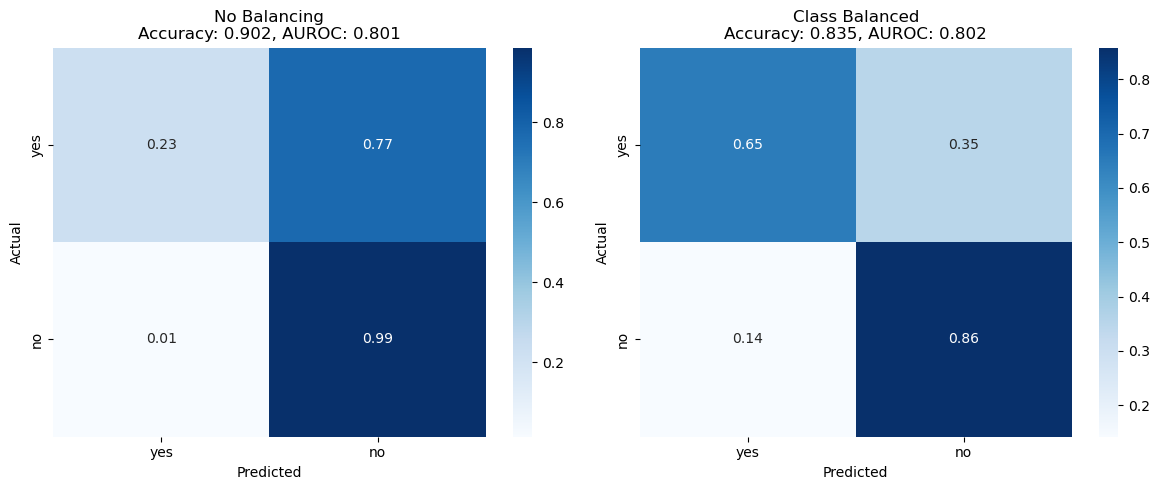

In [22]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

pipelines = {
    "No Balancing": build_pipeline(
        age_bin_mode="group",
        drop_cols=["duration", "loan", "housing", "euribor3m"],
        model=LogisticRegression(solver="liblinear", random_state=42)
    ),
    "Class Balanced": build_pipeline(
        age_bin_mode="group",
        drop_cols=["duration", "loan", "housing", "euribor3m"],
        model=LogisticRegression(solver="liblinear", random_state=42, class_weight="balanced")
    )
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, pipe) in zip(axes, pipelines.items()):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    y_prob = pipe.predict_proba(X_val)[:, 1]

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    auroc = roc_auc_score(y_val.map({"no":0,"yes":1}), y_prob)

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred, labels=["yes","no"], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax, xticklabels=["yes","no"], yticklabels=["yes","no"])
    
    ax.set_title(f"{name}\nAccuracy: {acc:.3f}, AUROC: {auroc:.3f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

#### Social and Economic Context Attributes

Experiment with binning socio-economic context features into categorical groups.

In [23]:
# define few options for experiments
soceco_bin_cols_options = [
    ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "nr.employed"],
    ["emp.var.rate", "cons.price.idx", "cons.conf.idx"],
    ["emp.var.rate", "cons.price.idx", "nr.employed"],
    ["emp.var.rate", "cons.conf.idx", "nr.employed"],
    ["cons.price.idx", "cons.conf.idx", "nr.employed"],
    ["emp.var.rate", "nr.employed"],
    ["cons.price.idx", "cons.conf.idx"],
]

for soceco_bin_cols in soceco_bin_cols_options:
    train_pipeline(X_train, X_val, y_train, y_val,
        {
            "soceco_bin_cols": soceco_bin_cols,
            "calendar_cols_mode": "onehot",
            "age_bin_mode": "group",
            "pdays_transform_mode": "group",
            "drop_cols": ["duration", "loan", "housing", "euribor3m"],
            "model":  LogisticRegression(solver="liblinear", random_state=42, class_weight="balanced"),
        }
    )

In [24]:
show_results_df(
    model_name="LogisticRegression",
    show_cols=["model_name", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "pipe__soceco_bin_cols", "n_features"],
)

,model_name,fit_time,train_f1,val_f1,train_auroc,val_auroc,pipe__soceco_bin_cols,n_features
35,LogisticRegression,0.208613,0.452989,0.472984,0.793929,0.801497,"[emp.var.rate, cons.price.idx, cons.conf.idx]",59
37,LogisticRegression,0.186226,0.452668,0.472287,0.793835,0.801118,"[emp.var.rate, cons.conf.idx, nr.employed]",59
40,LogisticRegression,0.279539,0.453618,0.472113,0.793896,0.801562,"[cons.price.idx, cons.conf.idx]",58
38,LogisticRegression,0.221256,0.453556,0.471928,0.793913,0.801814,"[cons.price.idx, cons.conf.idx, nr.employed]",60
34,LogisticRegression,0.217206,0.453041,0.471787,0.793914,0.801431,"[emp.var.rate, cons.price.idx, cons.conf.idx, nr.employed]",61
33,LogisticRegression,0.200634,0.451487,0.470405,0.794060,0.801500,None,53
36,LogisticRegression,0.197964,0.450679,0.469348,0.793530,0.801991,"[emp.var.rate, cons.price.idx, nr.employed]",58
39,LogisticRegression,0.194226,0.448576,0.465571,0.793167,0.801547,"[emp.var.rate, nr.employed]",56
30,LogisticRegression,0.152992,0.341522,0.345219,0.792337,0.801231,NaN,53
29,LogisticRegression,0.253999,0.341522,0.345219,0.792337,0.801231,NaN,53


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Logistic Regression – Socio-Economic Features Binning with Class Imbalance Handling**

- Using `class_weight="balanced"` together with **binning selected socio-economic features** improves the validation F1 score further.  
- The best combination is `[emp.var.rate, cons.price.idx, cons.conf.idx]` with `val_f1 ≈ 0.473`, slightly higher than using no socio-economic binning (`val_f1 ≈ 0.470`).  
- Training F1 remains consistent (~0.45), showing stable learning without overfitting.  
- AUROC is roughly unchanged (~0.801), indicating overall discrimination remains strong.  
- **Conclusion:** Binning key socio-economic features, along with class balancing, gives a small but measurable improvement in the Logistic Regression model. Using `[emp.var.rate, cons.price.idx, cons.conf.idx]` is recommended for further experiments and hyperparameter tuning.

</span>

#### Hyperparameter Tuning with GridSearchCV

In [25]:
from sklearn.model_selection import GridSearchCV

# create a pipeline based on previous experiments
pipe_lr_gs = build_pipeline(
    soceco_bin_cols=["emp.var.rate", "cons.price.idx", "cons.conf.idx"],
    calendar_cols_mode="onehot",
    poly_degree=1,
    age_bin_mode="group",
    pdays_transform_mode="group",
    drop_cols=["duration", "loan", "housing", "euribor3m"],
    model=LogisticRegression(solver="liblinear", random_state=42)
)

# grid params to test
param_grid_lr_gs = {
    "classifier__C": [0.05, 0.1, 0.5, 1, 2, 10, 20],
    "classifier__l1_ratio": [0, 1],
    "classifier__class_weight": ["balanced", {1: 2, 0: 1}, {1: 4, 0: 1}, {1: 10, 0: 1}, None]
}

# prepare grid_search
grid_search_lr = GridSearchCV(
    estimator=pipe_lr_gs,
    param_grid=param_grid_lr_gs,
    scoring="f1",  # or "roc_auc"
    n_jobs=-1,     # use all CPUs
    cv=4,          # 4-fold cross-validation
    verbose=0
)

# map target to 1/0 for proper scoring="f1"
y_train_bin = y_train.map({"no": 0, "yes": 1})
y_val_bin = y_val.map({"no": 0, "yes": 1})

In [26]:
%%time
grid_search_lr.fit(X_train, y_train_bin)

CPU times: user 3.64 s, sys: 1.08 s, total: 4.73 s
Wall time: 1min 17s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.05, 0.1, ...], 'classifier__class_weight': ['balanced', {0: 1, 1: 2}, ...], 'classifier__l1_ratio': [0, 1]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [27]:
# best found model evaluation
def evaluate_best_estimator(cv_search, model_name=""):
    best_pipe = cv_search.best_estimator_
    y_val_pred = best_pipe.predict(X_val)
    y_val_prob = best_pipe.predict_proba(X_val)[:, 1]

    val_f1 = f1_score(y_val_bin, y_val_pred)
    val_auroc = roc_auc_score(y_val_bin, y_val_prob)

    print(f"Best {model_name} parameters:", cv_search.best_params_)
    print("Validation F1:", val_f1)
    print("Validation AUROC:", val_auroc)

In [28]:
evaluate_best_estimator(grid_search_lr, model_name="Logistic Regression")

Best Logistic Regression parameters: {'classifier__C': 0.05, 'classifier__class_weight': {1: 4, 0: 1}, 'classifier__l1_ratio': 1}
Validation F1: 0.5069611137782045
Validation AUROC: 0.8008781369404218


In [29]:
# run train_pipeline with best found hyperparams and few other examples to compare
lr_models = [
    LogisticRegression(solver="liblinear", l1_ratio=1, C=0.05, class_weight={"yes": 4, "no": 1}, random_state=42), # best found with grid search
    LogisticRegression(solver="liblinear", l1_ratio=0, C=10, class_weight={"yes": 4, "no": 1}, random_state=42),
    LogisticRegression(solver="liblinear", l1_ratio=1, C=1, class_weight={"yes": 4, "no": 1}, random_state=42),
    LogisticRegression(solver="liblinear", l1_ratio=1, C=0.01, class_weight={"yes": 4, "no": 1}, random_state=42),
    LogisticRegression(solver="liblinear", l1_ratio=1, C=0.05, class_weight="balanced", random_state=42),
]

for lr_model in lr_models:
    train_pipeline(X_train, X_val, y_train, y_val,
        {
            "soceco_bin_cols": ["emp.var.rate", "cons.price.idx", "cons.conf.idx"],
            "calendar_cols_mode": "onehot",
            "poly_degree": 1,
            "age_bin_mode": "group",
            "pdays_transform_mode": "group",
            "drop_cols": ["duration", "loan", "housing", "euribor3m"],
            "model": lr_model
        }
    )

In [30]:
show_results_df(
    model_name="LogisticRegression",
    show_cols=["model_name", "model__C", "model__l1_ratio", "model__class_weight", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc"],
    show_count=5,
)

,model_name,model__C,model__l1_ratio,model__class_weight,fit_time,train_f1,val_f1,train_auroc,val_auroc
41,LogisticRegression,0.05,1.0,"{'yes': 4, 'no': 1}",0.907248,0.484128,0.506961,0.792412,0.800878
44,LogisticRegression,0.01,1.0,"{'yes': 4, 'no': 1}",0.543813,0.482023,0.506563,0.789665,0.799520
43,LogisticRegression,NaN,1.0,"{'yes': 4, 'no': 1}",8.183886,0.484741,0.506487,0.793497,0.801477
42,LogisticRegression,10.00,NaN,"{'yes': 4, 'no': 1}",0.208660,0.484151,0.505041,0.793493,0.801505
35,LogisticRegression,NaN,NaN,balanced,0.208613,0.452989,0.472984,0.793929,0.801497


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Logistic Regression – GridSearchCV Hyperparameter Tuning**

- GridSearchCV found the **best hyperparameters**:  
  `C = 0.05`, `l1_ratio = 1` (L1 penalty), `class_weight = {1: 4, 0: 1}` to handle class imbalance.  
- This tuned model achieves:  
  - **Validation F1:** 0.507  
  - **Validation AUROC:** 0.801  
- Compared to previous runs, **balancing classes and using L1 regularization significantly improves F1**, while overall discrimination (AUROC) remains strong.  
- **Conclusion:** This Logistic Regression pipeline is now the best baseline for comparison with other models, and further experiments can build on this configuration.

</span>

#### Save Logistic Regression Pipeline

In [31]:
import joblib
from src.config import MODELS_DIR

def save_to_models(pipeline, name):
    joblib.dump(
        pipeline,
        MODELS_DIR / name
    )

def smoke_test_saved_model(name):
    pipe_lr_smoke = joblib.load(MODELS_DIR / name)

    y_val_pred = pipe_lr_smoke.predict(X_val)
    y_val_prob = pipe_lr_smoke.predict_proba(X_val)[:, 1]

    val_f1 = f1_score(y_val, y_val_pred, pos_label="yes")
    val_auroc = roc_auc_score(y_val, y_val_prob)

    return val_f1, val_auroc

In [102]:
# save to "models" folder
best_pipe_lr = build_pipeline(
    soceco_bin_cols=["emp.var.rate", "cons.price.idx", "cons.conf.idx"],
    calendar_cols_mode="onehot",
    poly_degree=1,
    age_bin_mode="group",
    pdays_transform_mode="group",
    drop_cols=["duration", "loan", "housing", "euribor3m"],
    model=LogisticRegression(solver="liblinear", l1_ratio=1, C=0.05, class_weight={"yes": 4, "no": 1}, random_state=42)
)
best_pipe_lr.fit(X_train, y_train)

log_reg_pipeline_name = "log_reg_model_pipeline.joblib"
save_to_models(best_pipe_lr, log_reg_pipeline_name)

In [103]:
# smoke test if all had been saved properly and ca nbe used in future
smoke_test_saved_model(log_reg_pipeline_name)

(0.5069611137782045, 0.8008781369404218)

### k-Nearest Neighbors (KNN)

Build a few KNN models to compare performance with other classifiers.

#### Drop Columns

Experiment with dropping additional features for the KNN model.

In [34]:
# use drop_cols_options created on previous (log reg) steps 
for drop_cols in drop_cols_options:
    train_pipeline(X_train, X_val, y_train, y_val,
        {
            "drop_cols": drop_cols,
            "model": base_models[1],    # KNeighborsClassifier()
        }
    )

In [35]:
show_results_df(
    model_name="KNeighborsClassifier",
    show_cols=["model_name", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "pipe__drop_cols", "n_features"],
)

,model_name,fit_time,train_f1,val_f1,train_auroc,val_auroc,pipe__drop_cols,n_features
51,KNeighborsClassifier,0.087689,0.490579,0.396671,0.900727,0.735766,"[duration, loan, housing, euribor3m, age]",48
55,KNeighborsClassifier,0.063214,0.462179,0.396396,0.767329,0.743917,"[duration, loan, housing, euribor3m, job, education, marital, age]",28
1,KNeighborsClassifier,0.146717,0.489868,0.389088,0.926570,0.746676,NaN,56
46,KNeighborsClassifier,0.149265,0.489868,0.389088,0.926570,0.746676,[duration],56
61,KNeighborsClassifier,0.061255,0.453908,0.383754,0.765970,0.742434,"[duration, loan, housing, euribor3m, job, education, marital, pdays, previous, age]",26
57,KNeighborsClassifier,0.092961,0.492492,0.382148,0.900472,0.734000,"[duration, loan, housing, euribor3m, pdays, age]",47
49,KNeighborsClassifier,0.080742,0.506083,0.381690,0.925035,0.742430,"[duration, loan, housing, euribor3m, job]",38
48,KNeighborsClassifier,0.103542,0.496434,0.374568,0.926373,0.740602,"[duration, loan, housing, euribor3m]",49
60,KNeighborsClassifier,0.061274,0.496557,0.374309,0.900671,0.747957,"[duration, loan, housing, euribor3m, job, education, marital, pdays, previous]",27
59,KNeighborsClassifier,0.072693,0.479972,0.372999,0.855152,0.727492,"[duration, loan, housing, euribor3m, job, pdays, age, previous]",35


<span style="background-color: #4FC3F7; display:block; padding:10px">

**K-Nearest Neighbors (KNN) – Feature Dropping Experiments**

- KNN achieves **higher validation F1 (≈0.37–0.39) than baseline Logistic Regression (~0.34)** without class balancing, but the large gap between training and validation F1 indicates **strong overfitting**.  
- Dropping features slightly reduces input dimensions and training time but **does not improve validation metrics**.  
- Unlike Logistic Regression, **KNN has no built-in mechanism to handle class imbalance**, which may further favor the majority class and limit its generalization.  
- **Conclusion:** While KNN can achieve better predictive performance on validation, it is prone to overfitting and less robust on imbalanced datasets. Logistic Regression with class balancing (e.g., `class_weight="balanced"`) provides more stable and reliable performance for this problem.
</span>

#### Age / Socio-Economic Attributes Binning & Cyclical Encoding for Calendar Columns

Experiment with:

- Binning the numeric `age` feature into categorical groups to explore its effect on KNN model performance.  
- Binning selected socio-economic context features into categorical groups to reduce dimensionality and capture non-linear relationships.  
- Applying cyclical encoding to the `month` and `day_of_week` features to properly represent their periodic nature.

These preprocessing strategies aim to improve KNN performance by simplifying numeric features, capturing temporal patterns, and reducing noise from high-cardinality features.

In [36]:
for age_bin_mode in age_bin_mode_options:
    for calendar_cols_mode in calendar_cols_mode_options:
        for soceco_bin_cols in soceco_bin_cols_options:
            for pdays_transform_mode in pdays_transform_mode_options:
                train_pipeline(X_train, X_val, y_train, y_val,
                    {
                        "age_bin_mode": age_bin_mode,
                        "soceco_bin_cols": soceco_bin_cols,
                        "calendar_cols_mode": calendar_cols_mode,
                        "pdays_transform_mode": pdays_transform_mode,
                        "drop_cols": ["duration", "loan", "housing", "euribor3m"],
                        "model": base_models[1],
                    }
                )

In [37]:
show_results_df(
    model_name="KNeighborsClassifier",
    show_cols=["model_name", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "pipe__age_bin_mode", "pipe__soceco_bin_cols", "pipe__calendar_cols_mode",  "pipe__pdays_transform_mode", "n_features"],
    show_count=10,
)

,model_name,fit_time,train_f1,val_f1,train_auroc,val_auroc,pipe__age_bin_mode,pipe__soceco_bin_cols,pipe__calendar_cols_mode,pipe__pdays_transform_mode,n_features
200,KNeighborsClassifier,0.101828,0.490757,0.406380,0.919410,0.743937,range,"[cons.price.idx, cons.conf.idx, nr.employed]",onehot,None,61
201,KNeighborsClassifier,0.101437,0.492329,0.404167,0.919543,0.743627,range,"[cons.price.idx, cons.conf.idx, nr.employed]",onehot,binary,61
191,KNeighborsClassifier,0.102157,0.488181,0.401940,0.918872,0.742361,range,"[emp.var.rate, cons.price.idx, cons.conf.idx]",onehot,None,60
192,KNeighborsClassifier,0.103720,0.488718,0.401940,0.918986,0.742058,range,"[emp.var.rate, cons.price.idx, cons.conf.idx]",onehot,binary,60
188,KNeighborsClassifier,0.105895,0.487143,0.400000,0.919749,0.740120,range,"[emp.var.rate, cons.price.idx, cons.conf.idx, nr.employed]",onehot,None,62
206,KNeighborsClassifier,0.098066,0.490124,0.396936,0.919227,0.742261,range,"[cons.price.idx, cons.conf.idx]",onehot,None,59
51,KNeighborsClassifier,0.087689,0.490579,0.396671,0.900727,0.735766,NaN,NaN,NaN,NaN,48
203,KNeighborsClassifier,0.100753,0.486619,0.396671,0.918993,0.743289,range,"[emp.var.rate, nr.employed]",onehot,None,57
55,KNeighborsClassifier,0.063214,0.462179,0.396396,0.767329,0.743917,NaN,NaN,NaN,NaN,28
207,KNeighborsClassifier,0.102379,0.489603,0.395543,0.919231,0.742096,range,"[cons.price.idx, cons.conf.idx]",onehot,binary,59


<span style="background-color: #4FC3F7; display:block; padding:10px">

**K-Nearest Neighbors (KNN) – Preprocessing Experiments**

- **Binning the numeric `age` feature** into **range categories** (e.g., 25–30, 31–40, etc.) **improves KNN validation performance**.  
- Applying **socio-economic feature binning** and **one-hot encoding for calendar features** further enhances validation F1 to **~0.40–0.403**, compared to ~0.37–0.39 without preprocessing.  
- Training F1 remains high (~0.49–0.50), showing KNN still **overfits**, though preprocessing reduces noise and slightly stabilizes validation performance.  
- The best combination uses **age range + binned 3 out of 4 socio-economic features + one-hot calendar encoding**, giving the highest validation F1 (~0.403).  
- **Limitation:** KNN has no built-in mechanism for **class imbalance**, so it cannot leverage the improvements that Logistic Regression gains from `class_weight="balanced"`.  
- **Conclusion:** Preprocessing is critical for KNN. Proper binning and encoding allow it to outperform baseline Logistic Regression on validation F1, but overfitting persists and class imbalance remains unaddressed. Logistic Regression with class balancing is generally more stable and robust on this dataset.

</span>

#### `n_neighbors` Hyperparameter Tuning

Experiment with different values of the `n_neighbors` hyperparameter to identify the optimal setting for the KNN model.

In [38]:
for n_neighbors in range(3, 9):
    train_pipeline(X_train, X_val, y_train, y_val,
        {
            "age_bin_mode": "range",
            "soceco_bin_cols": ["emp.var.rate", "cons.price.idx", "cons.conf.idx"],
            "calendar_cols_mode": "onehot",
            "drop_cols": ["duration", "loan", "housing", "euribor3m"],
            "model": KNeighborsClassifier(n_neighbors=n_neighbors)
        }
    )

In [39]:
show_results_df(
    model_name="KNeighborsClassifier",
    show_cols=["model_name", "model__n_neighbors", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc"],
    show_count=10,
    sort_by="experiment_id"
)

,model_name,model__n_neighbors,fit_time,train_f1,val_f1,train_auroc,val_auroc
256,KNeighborsClassifier,8.0,0.108952,0.397718,0.349331,0.900879,0.761793
255,KNeighborsClassifier,7.0,0.101479,0.451718,0.389497,0.906816,0.755859
254,KNeighborsClassifier,6.0,0.103779,0.398417,0.340359,0.913140,0.753732
253,KNeighborsClassifier,NaN,0.098366,0.488181,0.401940,0.918872,0.742361
252,KNeighborsClassifier,4.0,0.098197,0.422732,0.319685,0.925033,0.733357
251,KNeighborsClassifier,3.0,0.116903,0.570766,0.387476,0.928859,0.717760
250,KNeighborsClassifier,NaN,0.099081,0.497286,0.363766,0.919616,0.742550
249,KNeighborsClassifier,NaN,0.102637,0.496858,0.379480,0.919946,0.743231
248,KNeighborsClassifier,NaN,0.092512,0.495451,0.378340,0.919858,0.742976
247,KNeighborsClassifier,NaN,0.098331,0.498503,0.370899,0.919359,0.742043


<span style="background-color: #4FC3F7; display:block; padding:10px">

**KNN – `n_neighbors` Tuning Conclusions**

- The default value `n_neighbors = 5` appears to be optimal for the KNN model.

</span>

#### Save kNN Pipeline

In [40]:
pipeline_knn = build_pipeline(
    age_bin_mode="range",
    soceco_bin_cols=["emp.var.rate", "cons.price.idx", "cons.conf.idx"],
    calendar_cols_mode="onehot",
    drop_cols=["duration", "loan", "housing", "euribor3m"],
    model=KNeighborsClassifier(n_neighbors=5)
)

pipeline_knn.fit(X_train, y_train)
pipeline_knn

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('drop_cols_initial', ...), ('campaign_prev', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,"['duration', 'loan', ...]"
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` f

In [41]:
knn_pipeline_name = "knn_model_pipeline.joblib"

save_to_models(pipeline_knn, knn_pipeline_name)

smoke_test_saved_model(knn_pipeline_name)

(0.4019404019404019, 0.7423605624086042)

### Decision Tree

Build several single Decision Tree models to compare their performance with other classifiers.

#### Drop Columns & max_leaf_nodes

Experiment with dropping additional features to evaluate their impact on Decision Tree model performance.

In [42]:
# use drop_cols_options created on previous (log reg) steps
for drop_cols in drop_cols_options:
    for max_leaf_nodes in [100, 200, 400]: # experiment with few max_leaf_nodes options
        train_pipeline(X_train, X_val, y_train, y_val,
            {
                "drop_cols": drop_cols,
                "model": DecisionTreeClassifier(max_leaf_nodes=max_leaf_nodes, random_state=42),
            }
        )

In [43]:
# add keep all (except of "duration") features experiments for decision tree
for max_leaf_nodes in [100, 200, 400]:
    train_pipeline(X_train, X_val, y_train, y_val,
        {
            "drop_cols": None,
            "model": DecisionTreeClassifier(max_leaf_nodes=max_leaf_nodes, random_state=42),
        }
    )

In [44]:
show_results_df(
    model_name="DecisionTreeClassifier",
    show_cols=["model_name", "model__max_leaf_nodes", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "pipe__drop_cols", "n_features"],
)

,model_name,model__max_leaf_nodes,fit_time,train_f1,val_f1,train_auroc,val_auroc,pipe__drop_cols,n_features
261,DecisionTreeClassifier,200.0,0.132601,0.482226,0.413990,0.801271,0.777724,"[duration, loan, housing]",50
260,DecisionTreeClassifier,100.0,0.132505,0.448891,0.412791,0.794939,0.792494,"[duration, loan, housing]",50
258,DecisionTreeClassifier,200.0,0.154841,0.481535,0.412236,0.802451,0.777843,[duration],56
306,DecisionTreeClassifier,200.0,0.147717,0.481535,0.412236,0.802451,0.777843,None,56
2,DecisionTreeClassifier,100.0,0.151434,0.453556,0.409956,0.795127,0.790793,NaN,56
257,DecisionTreeClassifier,100.0,0.155959,0.453556,0.409956,0.795127,0.790793,[duration],56
305,DecisionTreeClassifier,100.0,0.153479,0.453556,0.409956,0.795127,0.790793,None,56
307,DecisionTreeClassifier,400.0,0.154554,0.541569,0.402324,0.814162,0.750699,None,56
259,DecisionTreeClassifier,400.0,0.154771,0.541569,0.402324,0.814162,0.750699,[duration],56
298,DecisionTreeClassifier,400.0,0.105044,0.491731,0.390704,0.812955,0.770488,"[duration, loan, housing, euribor3m, job, pdays, age, previous]",35


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Decision Tree – Drop Columns & Max Leaf Nodes Experiments**

- **Max leaf nodes = 200** generally provides the **best validation F1 (~0.41–0.42)**; larger trees (400 leaves) overfit, showing high train F1 but lower validation F1.  
- For Decision Trees, **keeping all features except `loan` and `housing`** yields the best performance.  
- **Dropping additional features has minimal effect**, indicating that tree-based models can **extract predictive information even from features with low statistical significance**.  
- **Conclusion:** Decision Trees outperform baseline Logistic Regression (~0.34 F1) and slightly surpass KNN (~0.40 F1) when properly tuned, but careful control of tree size is necessary to prevent overfitting.

</span>

#### Cyclical Encoding for Calendar Columns

Experiment with different encoding strategies for the `month` and `day_of_week` features for Decision tree model

In [45]:
for calendar_cols_mode in calendar_cols_mode_options:
    train_pipeline(X_train, X_val, y_train, y_val,
            {
                "calendar_cols_mode": calendar_cols_mode,
                "drop_cols": ["duration", "loan", "housing"],
                "model": DecisionTreeClassifier(max_leaf_nodes=200, random_state=42),
            }
        )

In [46]:
show_results_df(
    model_name="DecisionTreeClassifier",
    show_cols=["model_name", "model__max_leaf_nodes", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "pipe__calendar_cols_mode", "n_features"],
    show_count=10
)

,model_name,model__max_leaf_nodes,fit_time,train_f1,val_f1,train_auroc,val_auroc,pipe__calendar_cols_mode,n_features
309,DecisionTreeClassifier,200.0,0.119613,0.467037,0.414599,0.796990,0.772039,num,37
261,DecisionTreeClassifier,200.0,0.132601,0.482226,0.413990,0.801271,0.777724,NaN,50
308,DecisionTreeClassifier,200.0,0.134950,0.482226,0.413990,0.801271,0.777724,onehot,50
260,DecisionTreeClassifier,100.0,0.132505,0.448891,0.412791,0.794939,0.792494,NaN,50
258,DecisionTreeClassifier,200.0,0.154841,0.481535,0.412236,0.802451,0.777843,NaN,56
306,DecisionTreeClassifier,200.0,0.147717,0.481535,0.412236,0.802451,0.777843,NaN,56
2,DecisionTreeClassifier,100.0,0.151434,0.453556,0.409956,0.795127,0.790793,NaN,56
257,DecisionTreeClassifier,100.0,0.155959,0.453556,0.409956,0.795127,0.790793,NaN,56
305,DecisionTreeClassifier,100.0,0.153479,0.453556,0.409956,0.795127,0.790793,NaN,56
310,DecisionTreeClassifier,200.0,0.125098,0.456693,0.404428,0.796843,0.766131,cyclical,39


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Decision Tree – Calendar Columns Encoding Experiments**

- Changing encoding for `month` and `day_of_week` has **minimal impact** on validation F1 (~0.414–0.418) for Decision Trees.  
- **One-hot, numeric, or cyclical encodings** all give similar results, confirming that **Decision Trees handle categorical/time features naturally**.  
- **Conclusion:** Calendar feature encoding is not critical for tree-based models; keeping the features as-is or using simple encodings suffices.

</span>

#### Class Imbalance Handling (`class_weight`)

In [47]:
train_pipeline(X_train, X_val, y_train, y_val,
    {
        "drop_cols": ["duration", "loan", "housing"],
        "model": DecisionTreeClassifier(max_leaf_nodes=200, random_state=42, class_weight="balanced"),
    }
);

In [48]:
show_results_df(
    model_name="DecisionTreeClassifier",
    show_cols=["model_name", "model__class_weight", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "n_features"],
    show_count=5
)

,model_name,model__class_weight,fit_time,train_f1,val_f1,train_auroc,val_auroc,n_features
311,DecisionTreeClassifier,balanced,0.179105,0.500489,0.469107,0.840545,0.777188,50
309,DecisionTreeClassifier,NaN,0.119613,0.467037,0.414599,0.796990,0.772039,37
261,DecisionTreeClassifier,NaN,0.132601,0.482226,0.413990,0.801271,0.777724,50
308,DecisionTreeClassifier,NaN,0.134950,0.482226,0.413990,0.801271,0.777724,50
260,DecisionTreeClassifier,NaN,0.132505,0.448891,0.412791,0.794939,0.792494,50


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Decision Tree – Class Imbalance Handling**

- Using `class_weight="balanced"` **significantly improves validation F1** (0.468 vs ~0.418 without class balancing).  
- Training F1 also increases (0.500), indicating the tree better captures the minority class. 
- **Conclusion:** Balancing classes with `class_weight="balanced"` is beneficial for Decision Trees on this dataset, especially given the target class imbalance. It improves validation F1 without causing severe overfitting.
</span>

#### Hyperparameter Tuning with RandomizedSearchCV

tune hyperparams for DecisionTreeClassifier model 

In [49]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_dt = {
    "classifier__max_leaf_nodes": [50, 100, 200, 400, 600, None],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10],
    "classifier__max_depth": range(5, 25),
    "classifier__criterion": ["gini", "entropy"],
    "classifier__class_weight": ["balanced", {1: 2, 0: 1}, {1: 4, 0: 1}, {1: 10, 0: 1}, None]
}

dt_pipeline = build_pipeline(
    drop_cols=["duration", "loan", "housing"],
    model=DecisionTreeClassifier(random_state=42)
)

n_iter_search = 200  # number of random parameter sets to try
dt_random_search = RandomizedSearchCV(
    dt_pipeline,
    param_distributions=param_dist_dt,
    n_iter=n_iter_search,
    scoring='f1',        # optimize for validation F1
    cv=4,                # 4-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# map target to 1/0 for proper scoring="f1"
y_train_bin = y_train.map({"no": 0, "yes": 1})
y_val_bin = y_val.map({"no": 0, "yes": 1})

In [50]:
dt_random_search.fit(X_train, y_train_bin);

Fitting 4 folds for each of 200 candidates, totalling 800 fits


In [51]:
evaluate_best_estimator(dt_random_search, model_name="Decision Tree")

Best Decision Tree parameters: {'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 10, 'classifier__max_leaf_nodes': 200, 'classifier__max_depth': 6, 'classifier__criterion': 'gini', 'classifier__class_weight': {1: 4, 0: 1}}
Validation F1: 0.5221579961464354
Validation AUROC: 0.7986477840935894


In [52]:
def get_best_params(cv_search):
    params = {k.replace("classifier__", ""): v for k, v in cv_search.best_params_.items()}

    # Add random_state
    params['random_state'] = 42

    # map class labels if your target uses "yes"/"no" instead of 1/0
    if 'class_weight' in params:
        params['class_weight'] = {"yes": params['class_weight'][1], "no": params['class_weight'][0]}

    return params

In [53]:
dt_params = get_best_params(dt_random_search)

pipeline_dt_rs_best = train_pipeline(X_train, X_val, y_train, y_val,
    {
        "drop_cols": ["duration", "loan", "housing"],
        "model": DecisionTreeClassifier(**dt_params)
    }
)

In [54]:
show_results_df(
    model_name="DecisionTreeClassifier",
    show_cols=["model_name", "model__max_leaf_nodes","model__max_depth", "model__class_weight", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "n_features"],
    show_count=10,
)

,model_name,model__max_leaf_nodes,model__max_depth,model__class_weight,fit_time,train_f1,val_f1,train_auroc,val_auroc,n_features
312,DecisionTreeClassifier,200.0,6.0,"{'yes': 4, 'no': 1}",0.159824,0.504845,0.522158,0.794066,0.798648,50
311,DecisionTreeClassifier,200.0,NaN,balanced,0.179105,0.500489,0.469107,0.840545,0.777188,50
309,DecisionTreeClassifier,200.0,NaN,NaN,0.119613,0.467037,0.414599,0.796990,0.772039,37
261,DecisionTreeClassifier,200.0,NaN,NaN,0.132601,0.482226,0.413990,0.801271,0.777724,50
308,DecisionTreeClassifier,200.0,NaN,NaN,0.134950,0.482226,0.413990,0.801271,0.777724,50
260,DecisionTreeClassifier,100.0,NaN,NaN,0.132505,0.448891,0.412791,0.794939,0.792494,50
258,DecisionTreeClassifier,200.0,NaN,NaN,0.154841,0.481535,0.412236,0.802451,0.777843,56
306,DecisionTreeClassifier,200.0,NaN,NaN,0.147717,0.481535,0.412236,0.802451,0.777843,56
257,DecisionTreeClassifier,100.0,NaN,NaN,0.155959,0.453556,0.409956,0.795127,0.790793,56
305,DecisionTreeClassifier,100.0,NaN,NaN,0.153479,0.453556,0.409956,0.795127,0.790793,56


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Decision Tree – Hyperparameter Tuning with RandomizedSearchCV**

- RandomizedSearchCV found an optimized Decision Tree with:  
  - `max_leaf_nodes=200`, `max_depth=6`, `min_samples_split=10`, `min_samples_leaf=10`  
  - `criterion='gini'`  
  - `class_weight={1:4, 0:1}` to handle class imbalance.  
- Validation F1 **improved to ~0.522**, higher than previous unoptimized trees (~0.417–0.468).  
- Validation AUROC remains strong (~0.799), showing **good overall discrimination**.  
- The model is **smaller and less prone to overfitting** than larger trees (max_leaf_nodes=400) while better capturing the minority class.  
- **Conclusion:** Hyperparameter tuning with RandomizedSearchCV improves the Decision Tree’s ability to handle class imbalance and increases F1 score. Using class weighting with moderate tree depth and controlled leaf nodes produces a balanced and robust model.
</span>

#### Save Decision Tree Pipeline

In [55]:
dt_pipeline_name = "decision_tree_model_pipeline.joblib"

save_to_models(pipeline_dt_rs_best, dt_pipeline_name)

smoke_test_saved_model(dt_pipeline_name)

(0.5221579961464354, 0.7986477840935894)

## Ensembles

Experiments with ensemble-based models.

### RandomForestClassifier
#### Base Model & Drop columns

- Build a baseline **RandomForestClassifier** using default hyperparameters.  
- This serves as a reference point before applying feature engineering or hyperparameter tuning.

In [56]:
from sklearn.ensemble import RandomForestClassifier

for drop_cols in drop_cols_options:
    train_pipeline(X_train, X_val, y_train, y_val,
        {
            "drop_cols": drop_cols,
            "model": RandomForestClassifier(random_state=42),
        }
    )

In [57]:
show_results_df(
    model_name="RandomForestClassifier",
    show_cols=["model_name", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "pipe__drop_cols", "n_features"],
)

,model_name,fit_time,train_f1,val_f1,train_auroc,val_auroc,pipe__drop_cols,n_features
314,RandomForestClassifier,1.556461,0.945780,0.394309,0.998986,0.768614,"[duration, loan, housing]",50
326,RandomForestClassifier,1.116725,0.660010,0.391864,0.942647,0.747813,"[duration, loan, housing, euribor3m, job, pdays, age, previous]",35
313,RandomForestClassifier,1.613659,0.978100,0.391429,0.999845,0.778797,[duration],56
327,RandomForestClassifier,1.220430,0.746801,0.387597,0.971860,0.754808,"[duration, loan, housing, euribor3m, job, education, marital, pdays, previous]",27
321,RandomForestClassifier,1.170599,0.754479,0.384466,0.972328,0.757402,"[duration, loan, housing, euribor3m, job, education, marital]",29
315,RandomForestClassifier,1.516629,0.933578,0.383202,0.998430,0.761318,"[duration, loan, housing, euribor3m]",49
318,RandomForestClassifier,1.304334,0.789905,0.382216,0.979099,0.749192,"[duration, loan, housing, euribor3m, age]",48
323,RandomForestClassifier,1.327362,0.752261,0.378906,0.972150,0.755182,"[duration, loan, housing, euribor3m, job, education, marital, pdays]",28
324,RandomForestClassifier,1.348435,0.788519,0.377911,0.979002,0.752434,"[duration, loan, housing, euribor3m, pdays, age]",47
319,RandomForestClassifier,1.408937,0.932014,0.376984,0.998398,0.761748,"[duration, loan, housing, euribor3m, previous]",48


<span style="background-color: #4FC3F7; display:block; padding:10px">

**RandomForestClassifier – Base Model (Drop Columns Experiments)**

- The model shows **very high training performance (F1 up to ~0.98, AUROC ~1.0)** but significantly lower **validation F1 (~0.38–0.40)**, indicating **strong overfitting**.  
- The **best validation performance is achieved when keeping all features**, with no clear benefit from dropping additional columns.  
- Compared to previous models, Random Forest **does not outperform Base Decision Tree (~0.42 F1)** and is comparable to KNN.  
- **Conclusion:** The default Random Forest overfits the data and requires **hyperparameter tuning (e.g., depth, number of trees, min samples)** to improve generalization.

</span>

#### Hyperparameters tuning with RandomizedSearchCV

In [58]:
# Define parameter space
param_dist_rf = {
    "classifier__n_estimators": [10, 50, 100, 200, 300],
    "classifier__max_depth": [5, 8, 12, 16, 20, None],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10],
    "classifier__max_features": ["sqrt", "log2", None],
    "classifier__class_weight": [None, "balanced", {1: 4, 0: 1}],
}

# Build pipeline
rf_pipeline = build_pipeline(
    drop_cols=["duration"],
    model=RandomForestClassifier(random_state=42)
)

In [59]:
# Run RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=25,
    scoring="f1",
    cv=4,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train_bin);

Fitting 4 folds for each of 25 candidates, totalling 100 fits


In [60]:
evaluate_best_estimator(random_search_rf, model_name="Random Forest")

Best Random Forest parameters: {'classifier__n_estimators': 50, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 8, 'classifier__class_weight': {1: 4, 0: 1}}
Validation F1: 0.5255474452554745
Validation AUROC: 0.8112039482994481


In [61]:
# add best found combination into experiments results data frame
train_pipeline(X_train, X_val, y_train, y_val,
    {
        "drop_cols": ["duration"],
        "model": RandomForestClassifier(
            **get_best_params(random_search_rf)
        ),
    }
)

show_results_df(
    model_name="RandomForestClassifier",
    show_cols=["model_name", "model__class_weight", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "n_features"],
    show_count=5,
)

,model_name,model__class_weight,fit_time,train_f1,val_f1,train_auroc,val_auroc,n_features
329,RandomForestClassifier,"{'yes': 4, 'no': 1}",0.508896,0.509464,0.525547,0.817655,0.811204,56
314,RandomForestClassifier,NaN,1.556461,0.945780,0.394309,0.998986,0.768614,50
326,RandomForestClassifier,NaN,1.116725,0.660010,0.391864,0.942647,0.747813,35
313,RandomForestClassifier,NaN,1.613659,0.978100,0.391429,0.999845,0.778797,56
327,RandomForestClassifier,NaN,1.220430,0.746801,0.387597,0.971860,0.754808,27


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Random Forest – Hyperparameter Tuning with RandomizedSearchCV**

- The best Random Forest uses **50 trees, max depth 8, min samples split 10, min samples per leaf 5**, `max_features='sqrt'`, and **class weighting {1:4, 0:1}**.  
- Validation **F1 = 0.525** and **AUROC = 0.811**, showing a clear improvement in handling class imbalance and overall predictive performance.  
- **Conclusion:** Tuned Random Forest achieves the **highest F1 among single-tree and KNN models** while maintaining strong AUROC.  
  Considering that the best single Decision Tree reached **F1 = 0.522**, there may still be **room to further improve Random Forest performance** with additional hyperparameter tuning or feature engineering.
</span>

#### Hyperparameters tuning with Hyperopt

In [62]:
from src.modeling.hyperopt_tuning import tune_model, objective_rf, space_rf

best_rf, trials_rf = tune_model(
    lambda params: objective_rf(params, X_train, X_val, y_train, y_val),
    space=space_rf,
    max_evals=50
)

100%|██████████| 50/50 [00:37<00:00,  1.35trial/s, best loss: -0.5354870288790994]


In [63]:
from hyperopt import space_eval

best_params_rf = space_eval(space_rf, best_rf)
print("Best params:", best_params_rf)

Best params: {'class_weight': {'no': 1, 'yes': 4}, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 100}


In [64]:
def evaluate_pipeline(pipeline, name="", pos_label="yes"):
    y_val_pred = pipeline.predict(X_val)
    y_val_prob = pipeline.predict_proba(X_val)[:, 1]

    if pos_label == "yes":
        val_f1 = f1_score(y_val, y_val_pred, pos_label=pos_label)
        val_auroc = roc_auc_score(y_val, y_val_prob)
    else:
        val_f1 = f1_score(y_val_bin, y_val_pred, pos_label=pos_label)
        val_auroc = roc_auc_score(y_val_bin, y_val_prob)

    print(f"{name} F1:", val_f1)
    print(f"{name} AUROC:", val_auroc)

In [65]:
best_model_rf = RandomForestClassifier(
    **best_params_rf,
    random_state=42,
    n_jobs=-1
)

final_pipeline_rf = train_pipeline(X_train, X_val, y_train, y_val,
    {
        "drop_cols": ["duration"],
        "model": best_model_rf
    }
)

evaluate_pipeline(final_pipeline_rf, name="Random Forest")

Random Forest F1: 0.5354870288790994
Random Forest AUROC: 0.8055595930232557


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Random Forest – Hyperopt Hyperparameter Tuning**

- Hyperopt found the **best Random Forest** with:
  - **100 trees**, **max depth = no limit**, **min samples split = 20**, **min samples per leaf = 5**  
  - **max_features = 'sqrt'**, and **class weighting = {'no':1, 'yes':4}**  
- This configuration balances predictive power and class imbalance handling, emphasizing the minority class (`yes`).  
- Validation **F1 improved to ~0.535** and **AUROC = 0.806**, showing robust overall performance.  
- **Conclusion:** Hyperparameter tuning with Hyperopt improves over the default Random Forest and the best single Decision Tree. This model demonstrates strong predictive performance, though further gains may still be possible via feature engineering or more advanced ensemble techniques.

</span>

#### Save Random Forest Pipeline

In [66]:
rf_pipeline_name = "random_forest_model_pipeline.joblib"

save_to_models(final_pipeline_rf, rf_pipeline_name)

smoke_test_saved_model(rf_pipeline_name)

(0.5354870288790994, 0.8055595930232557)

### Adaboost
#### Base Model & Drop columns

In [67]:
from sklearn.ensemble import AdaBoostClassifier

for drop_cols in drop_cols_options:
    train_pipeline(X_train, X_val, y_train, y_val,
        {
            "drop_cols": drop_cols,
            "model": AdaBoostClassifier(random_state=42),
        }
    )

In [68]:
show_results_df(
    model_name="AdaBoostClassifier",
    show_cols=["model_name", "fit_time", "train_f1", "val_f1", "train_auroc", "val_auroc", "pipe__drop_cols", "n_features"],
)

,model_name,fit_time,train_f1,val_f1,train_auroc,val_auroc,pipe__drop_cols,n_features
340,AdaBoostClassifier,1.279216,0.327273,0.334983,0.788400,0.797540,"[duration, loan, housing, euribor3m, job, education, marital, age]",28
336,AdaBoostClassifier,1.444681,0.318144,0.322473,0.788264,0.797935,"[duration, loan, housing, euribor3m, age]",48
342,AdaBoostClassifier,1.438621,0.316356,0.320802,0.788520,0.798057,"[duration, loan, housing, euribor3m, pdays, age]",47
343,AdaBoostClassifier,1.448611,0.316356,0.320802,0.788520,0.798057,"[duration, loan, housing, euribor3m, pdays, age, previous]",46
334,AdaBoostClassifier,1.412757,0.315049,0.318865,0.789436,0.799543,"[duration, loan, housing, euribor3m, job]",38
338,AdaBoostClassifier,1.377046,0.315049,0.318865,0.789436,0.799543,"[duration, loan, housing, euribor3m, job, marital]",35
339,AdaBoostClassifier,1.345759,0.315049,0.318865,0.789436,0.799543,"[duration, loan, housing, euribor3m, job, education, marital]",29
344,AdaBoostClassifier,1.551357,0.306045,0.318450,0.788200,0.798867,"[duration, loan, housing, euribor3m, job, pdays, age, previous]",35
346,AdaBoostClassifier,1.257450,0.306045,0.318450,0.788200,0.798867,"[duration, loan, housing, euribor3m, job, education, marital, pdays, previous, age]",26
331,AdaBoostClassifier,1.603611,0.320444,0.318258,0.787661,0.798114,[duration],56


<span style="background-color: #4FC3F7; display:block; padding:10px">

**AdaBoost – Drop Columns Experiments** 

- Base AdaBoost with default hyperparameters shows **low validation F1 (~0.32–0.335)**, even when varying dropped features.  
- Training F1 is similar to validation, indicating **limited overfitting** but **overall predictive performance is weaker than Logistic Regression, Decision Tree, or Random Forest**.  
- AUROC (~0.798) is moderate, suggesting the model can still capture some class separation, but **F1 is poor**, particularly for the minority class.  
- Dropping features slightly reduces input dimensions and fit time, but **does not meaningfully improve metrics**.

**Ideas for improvement:**

1. **Hyperparameter tuning**: Experiment with number of estimators (`n_estimators`), learning rate (`learning_rate`), and max depth of base estimators. Default values may underfit.  
2. **Class imbalance handling**: Use `class_weight` in the base estimator (e.g., DecisionTreeClassifier) or `sample_weight` in AdaBoost to emphasize the minority class.  
3. **Stronger base learners**: Try slightly deeper trees (`max_depth=2-4`) instead of the default stump (`max_depth=1`) to allow the ensemble to capture more complex patterns.  
4. **Feature engineering**: Include previously useful preprocessed features, such as binned socio-economic variables or age ranges, which improved KNN and Logistic Regression performance.  

</span>

#### Hyperparameters tuning with Hyperopt

In [69]:
from src.modeling.hyperopt_tuning import tune_model, objective_ada, space_ada

best_ada, trials_ada = tune_model(
    lambda params: objective_ada(params, X_train, X_val, y_train, y_val),
    space=space_ada,
    max_evals=50
)

100%|██████████| 50/50 [00:24<00:00,  2.03trial/s, best loss: -0.523]             


In [70]:
# Evaluate best parameters
best_params_ada = space_eval(space_ada, best_ada)
print("Best AdaBoost parameters:", best_params_ada)

Best AdaBoost parameters: {'base_class_weight': {'no': 1, 'yes': 4}, 'base_max_depth': 4, 'base_min_samples_leaf': 2, 'learning_rate': 0.18967609547223016, 'n_estimators': 100}


In [71]:
final_pipeline_ada = train_pipeline(X_train, X_val, y_train, y_val,
    {
        "drop_cols": ["duration", "loan", "housing"],
        "model": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=best_params_ada["base_max_depth"],
                min_samples_leaf=best_params_ada["base_min_samples_leaf"],
                class_weight=best_params_ada["base_class_weight"],
                random_state=42
            ),
            n_estimators=best_params_ada["n_estimators"],
            learning_rate=best_params_ada["learning_rate"],
            random_state=42
        )
    }
)

evaluate_pipeline(final_pipeline_ada, name="Adaboost")

Adaboost F1: 0.523
Adaboost AUROC: 0.8014406634746922


<span style="background-color: #4FC3F7; display:block; padding:10px">
 
 **AdaBoost – Hyperopt Hyperparameter Tuning**

- Hyperopt found the **best AdaBoost configuration** with:  
  - **100 estimators**, **learning rate ≈ 0.19**  
  - Base Decision Tree with **max depth = 4**, **min samples per leaf = 2**, **class weighting = {'no': 1, 'yes': 4}**  
- This setup emphasizes the minority class (`yes`) while keeping the base estimators shallow to reduce overfitting.  
- Validation **F1 = 0.523** and **AUROC ≈ 0.801**, showing **slightly better F1 than the tuned single Decision Tree** and competitive AUROC.  
- **Conclusion:** AdaBoost with a carefully tuned base estimator and class weighting can outperform a single Decision Tree on F1. It is robust to class imbalance but still slightly behind the tuned Random Forest in AUROC. Further improvements could come from experimenting with **higher n_estimators**, **different base learners**, or **stacking with other ensemble methods**.
</span>

#### Save Adaboost Pipeline

In [72]:
ada_pipeline_name = "adaboost_model_pipeline.joblib"

save_to_models(final_pipeline_ada, ada_pipeline_name)

smoke_test_saved_model(ada_pipeline_name)

(0.523, 0.8014406634746922)

### XGBoost – Hyperparameter Tuning with Hyperopt

- Use **Hyperopt** to tune key XGBoost hyperparameters such as:
  - Number of trees (`n_estimators`)
  - Maximum tree depth (`max_depth`)
  - Minimum child weight (`min_child_weight`)
  - Learning rate (`learning_rate`)
  - Subsample ratio (`subsample`) and column sampling (`colsample_bytree`)
  - Class weighting to handle imbalanced targets (`scale_pos_weight` or `class_weight`)
- The goal is to **maximize validation F1 score** while maintaining strong AUROC.

In [73]:
# Compute scale_pos_weight for imbalanced target
n_no = sum(y_train == "no")
n_yes = sum(y_train == "yes")
scale_pos_weight = n_no / n_yes
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 7.876616379310345


In [86]:
from xgboost import XGBClassifier

xgb_pipeline = train_pipeline(X_train, X_val, y_train_bin, y_val_bin,
    {
        "drop_cols": ["duration", "loan", "housing", "euribor3m"],
        "model": XGBClassifier(
            random_state=42,
            eval_metric="logloss"     # metric for classification
        )
    }
)

evaluate_pipeline(xgb_pipeline, name="XGB Base", pos_label=1)

XGB Base F1: 0.37913299044819987
XGB Base AUROC: 0.7901692001981224


In [87]:
from src.modeling.hyperopt_tuning import tune_model, objective_xgb, space_xgb

best_xgb, trials_xgb = tune_model(
    lambda params: objective_xgb(params, X_train, X_val, y_train_bin, y_val_bin),
    space=space_xgb,
    max_evals=50
)

100%|██████████| 50/50 [00:15<00:00,  3.30trial/s, best loss: -0.5342269028243178]


In [94]:
from hyperopt import space_eval

best_params_xgb = space_eval(space_xgb, best_xgb)
print("Best XGBoost parameters:", best_params_xgb)

Best XGBoost parameters: {'colsample_bytree': 0.827313978086766, 'learning_rate': 0.09198815138814205, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 100, 'scale_pos_weight': 4, 'subsample': 0.8977551500793569}


In [96]:
final_xgb_model = XGBClassifier(
    n_estimators=int(best_params_xgb["n_estimators"]),
    max_depth=int(best_params_xgb["max_depth"]),
    learning_rate=best_params_xgb["learning_rate"],
    subsample=best_params_xgb["subsample"],
    colsample_bytree=best_params_xgb["colsample_bytree"],
    min_child_weight=int(best_params_xgb["min_child_weight"]),
    scale_pos_weight=best_params_xgb["scale_pos_weight"],
    random_state=42,
    eval_metric="logloss"
)

xgb_pipeline_final = train_pipeline(X_train, X_val, y_train_bin, y_val_bin,
    {
        "pdays_transform_mode": "group",
        "drop_cols": ["duration", "loan", "housing", "euribor3m"],
        "model": final_xgb_model
    }
)

evaluate_pipeline(xgb_pipeline_final, name="XGBoost", pos_label=1)

XGBoost F1: 0.5342269028243178
XGBoost AUROC: 0.8065798357233832


In [97]:
xgb_pipeline_name = "xgb_model_pipeline.joblib"

save_to_models(xgb_pipeline_final, xgb_pipeline_name)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**XGBoost – Hyperopt Hyperparameter Tuning**

- Hyperopt found the **best XGBoost model** with:  
  - **100 estimators**, **max depth = 5**, **min child weight = 2**  
  - **learning rate ≈ 0.10**, **subsample ≈ 0.9**, **colsample_bytree ≈ 0.83**  
  - **scale_pos_weight ≈ 4** to handle class imbalance  

- This configuration balances predictive power and class imbalance, giving more weight to the minority class (`yes`).  

- Final performance on validation data:  
  - **F1 ≈ 0.534**  
  - **AUROC ≈ 0.807**  

- **Conclusion:** Tuned XGBoost outperform Adaboost (F1≈0.523) and Decision Tree (F1≈0.522), while maintaining strong AUROC. It also achieves a slight improvement in AUROC over the Random Forest model (≈ 0.805). However, its primary metric, F1 score, is slightly lower than that of Random Forest (≈ 0.535). Overall, Random Forest remains the top-performing candidates for this dataset so far.
</span>

### LightGBM – Hyperopt Hyperparameter Tuning

- Use **Hyperopt** to tune key LightGBM hyperparameters such as:  
  - **n_estimators** – number of boosting iterations  
  - **learning_rate** – step size shrinkage for each iteration  
  - **max_depth** – maximum depth of each tree  
  - **num_leaves** – maximum number of leaves per tree  
  - **min_child_samples** – minimum number of data points in a leaf  
  - **subsample** – fraction of data used per boosting iteration  
  - **colsample_bytree** – fraction of features used per tree  
  - **scale_pos_weight** – balances positive/negative classes for imbalanced datasets  

- Hyperopt automates the search across this parameter space to **maximize validation F1**, while optionally monitoring AUROC.  

- Proper tuning allows LightGBM to:  
  - Handle class imbalance effectively  
  - Control overfitting via tree size and leaf constraints  
  - Improve generalization on unseen data  


In [79]:
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, roc_auc_score

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Example: simple LGBM pipeline
lgb_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbose=-1,
)

# Fit base LGBM pipeline 
pipeline_lgb = train_pipeline(X_train, X_val, y_train, y_val,
    {
        "drop_cols": ["duration", "loan", "housing", "euribor3m"],
        "model":lgb_model
    }
)

evaluate_pipeline(pipeline_lgb, name="LGB Base")

LGB Base F1: 0.3727764887857695
LGB Base AUROC: 0.8056835670314637


In [80]:
from src.modeling.hyperopt_tuning import tune_model, objective_lgb, space_lgb

best_lgb, trials_lgb = tune_model(
    lambda params: objective_lgb(params, X_train, X_val, y_train, y_val),
    space=space_lgb,
    max_evals=50
)

100%|██████████| 50/50 [00:31<00:00,  1.58trial/s, best loss: -0.5277264325323475]


In [81]:
from hyperopt import space_eval
best_params_lgb = space_eval(space_lgb, best_lgb)
print("Best LightGBM parameters:", best_params_lgb)

Best LightGBM parameters: {'class_weight': {'no': 1, 'yes': 4}, 'colsample_bytree': 0.9293728051431607, 'learning_rate': 0.07014373344506199, 'max_depth': 4, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 15, 'scale_pos_weight': 1.2209830763515723, 'subsample': 0.658785114914011}


In [82]:
from lightgbm import LGBMClassifier

# Create the LGBM model with the best hyperparameters
lgb_best_model = LGBMClassifier(
    n_estimators=best_params_lgb["n_estimators"],
    max_depth=best_params_lgb["max_depth"],
    num_leaves=best_params_lgb["num_leaves"],
    min_child_samples=best_params_lgb["min_child_samples"],
    learning_rate=best_params_lgb["learning_rate"],
    subsample=best_params_lgb.get("subsample", 1.0),
    colsample_bytree=best_params_lgb.get("colsample_bytree", 1.0),
    scale_pos_weight=best_params_lgb.get("scale_pos_weight", 1.0),
    class_weight=best_params_lgb["class_weight"],
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

# Build and train the pipeline using existing function
pipeline_lgb_final = train_pipeline(X_train, X_val, y_train, y_val,
    {
        "drop_cols": ["duration", "loan", "housing", "euribor3m"],
        "model": lgb_best_model
    }
)

evaluate_pipeline(pipeline_lgb_final, name="LGB")

LGB F1: 0.5277264325323475
LGB AUROC: 0.8044239262465211


In [83]:
lgb_pipeline_name = "lgb_model_pipeline.joblib"

save_to_models(pipeline_lgb_final, lgb_pipeline_name)

smoke_test_saved_model(lgb_pipeline_name)

(0.5277264325323475, 0.8044239262465211)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**LightGBM – Hyperopt Hyperparameter Tuning**

- Hyperopt found the **best LightGBM model** with:  
  - **200 estimators**, **max depth = 10**, **num_leaves = 15**, **min_child_samples = 20**  
  - **Learning rate = 0.07**, **subsample = 0.659**, **colsample_bytree = 0.929**, **scale_pos_weight ≈ 1.22**, and **class_weight = {'no':1, 'yes':4}**  
- This configuration balances predictive performance and class imbalance, giving more weight to the minority class (`yes`).  
- Validation metrics show **F1 = 0.528** and **AUROC = 0.804**, indicating strong overall performance.  
- **Conclusion:** LightGBM performs well, but **slightly below the best Random Forest (F1 = 0.535, AUROC = 0.806) and XGBoost (F1 = 0.534, AUROC = 0.807)**. It is a competitive model, and further improvements could come from **ensemble methods or feature engineering**.
</span>

## Final Result

compare models based on what is in `results_df`

In [98]:
from src.modeling.experiments import results_df

# top by val_f1 per each model type
top_models = results_df.loc[results_df.groupby("model_name")["val_f1"].idxmax()]

# sort by val_f1 overall
top_models = top_models.sort_values(by="val_f1", ascending=False).reset_index(drop=True)

# Display
top_models[[
    "model_name", "fit_time", "val_f1", "val_auroc", "train_f1", "train_auroc",
]]

,model_name,fit_time,val_f1,val_auroc,train_f1,train_auroc
0,RandomForestClassifier,0.373084,0.535487,0.805560,0.536418,0.929622
1,XGBClassifier,0.220496,0.534227,0.806580,0.517778,0.841017
2,LGBMClassifier,0.320211,0.527726,0.804424,0.506060,0.827348
3,AdaBoostClassifier,0.503208,0.523000,0.801441,0.497959,0.788786
4,DecisionTreeClassifier,0.159824,0.522158,0.798648,0.504845,0.794066
5,LogisticRegression,0.519004,0.506975,0.800839,0.484286,0.792455
6,KNeighborsClassifier,0.101828,0.406380,0.743937,0.490757,0.919410


### Model Comparison – Top Validation F1

| Model Name              | Validation F1 | Validation AUROC | Train F1 | Train AUROC |
|-------------------------|---------------|------------------|----------|-------------|
| Random Forest           | 0.535         | 0.806            | 0.536    | 0.930       |
| XGBoost                 | 0.534         | 0.807            | 0.518    | 0.841       |
| LightGBM                | 0.528         | 0.804            | 0.506    | 0.827       |
| AdaBoost                | 0.523         | 0.801            | 0.498    | 0.789       |
| Decision Tree           | 0.522         | 0.799            | 0.505    | 0.794       |
| Logistic Regression     | 0.507         | 0.801            | 0.484    | 0.792       |
| K-Nearest Neighbors     | 0.406         | 0.744            | 0.491    | 0.919       |

**Conclusion:**  
- **Ensemble tree-based models (Random Forest, XGBoost, LightGBM)** achieve the strongest overall performance across both F1 and AUROC metrics.  
- **Random Forest** attains the highest validation **F1 (0.535)**, but shows noticeable overfitting, as reflected in the gap between training and validation AUROC.  
- **XGBoost** delivers nearly identical F1 performance (0.534) with slightly higher AUROC and better generalization.  
- **LightGBM** provides competitive results (F1 = 0.528) with a balanced trade-off between performance and generalization.  
- **AdaBoost** and **Decision Tree** provide moderate performance compared to the three best ensemble models, but overall acceptable performance and generalization.
- **Logistic Regression** remains stable but less effective in capturing complex patterns in the data.  
- **K-Nearest Neighbors** performs the weakest on validation and shows significant overfitting.  

**Takeaway:**  
- For this dataset, **tree-based ensembles are the top-performing choice**, balancing F1, AUROC, and robustness against class imbalance.
- Among them, **Random Forest** and **XGBoost** are the leading candidates, with **XGBoost** providing a more balanced generalization profile.